## Environment & Library Setup

In [155]:
import os
import sys

venv_path = os.path.abspath(r"..\granola.ai\Lib\site-packages")
if venv_path not in sys.path:
    sys.path.insert(0, venv_path)

In [156]:
import os
import re
import warnings
from collections import Counter
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [157]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
sns.set_theme(style="darkgrid")
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shaar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 1. Data Loading

In [158]:
base_dir = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
data_path = os.path.join(base_dir, "data", "dataset.csv")

In [159]:
df = pd.read_csv(data_path)
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## 2. Data Overview

In [160]:
nums_rows, nums_columns = df.shape
print(f"Number of rows: {nums_rows}\nNumber of columns: {nums_columns}")

Number of rows: 8519
Number of columns: 17


In [161]:
duplicate = df.duplicated().any()
duplicate

np.False_

In [162]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8519 entries, 0 to 8518
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8519 non-null   int64  
 1   Customer Name                 8519 non-null   str    
 2   Customer Email                8519 non-null   str    
 3   Customer Age                  8519 non-null   int64  
 4   Customer Gender               8519 non-null   str    
 5   Product Purchased             8519 non-null   str    
 6   Date of Purchase              8519 non-null   str    
 7   Ticket Type                   8519 non-null   str    
 8   Ticket Subject                8519 non-null   str    
 9   Ticket Description            8519 non-null   str    
 10  Ticket Status                 8519 non-null   str    
 11  Resolution                    2801 non-null   str    
 12  Ticket Priority               8519 non-null   str    
 13  Ticket Channel

In [203]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5718
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5714
dtype: int64

**FINDINGS:**

* Features: Customer Info (Name, Email, Age, Gender), Purchase Info (Product Purchased, Date of Purchase), Ticket Info (Ticket ID, Subject, Description, Priority, Channel, Status, Resolution), and Time Metrics (First Response Time, Time to Resolution).
* Target Feature: "Ticket Type"
* No duplicates are present in the dataset. 
* Features like "Resolution", "First Response Time", "Time to resolution", and "Customer Satisfaction Rating" have extremely high NULL values.

##  3. Data Preprocessing & Feature Engineering

### 3.1 Datetime Parsing & Missing Value Imputation

In [163]:
df["Date of Purchase"] = pd.to_datetime(df["Date of Purchase"], format="%Y-%m-%d")
df["First Response Time"] = pd.to_datetime(df["First Response Time"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
df["Time to Resolution"] = pd.to_datetime(df["Time to Resolution"], format="%Y-%m-%d %H:%M:%S", errors="coerce")

In [164]:
# Ticket ID columns is similar to the index of table so drop it
df_ticket = df.drop(columns=["Ticket ID"])

In [165]:
df_ticket["Resolution"] = df_ticket["Resolution"].fillna("None")
df_ticket["First Response Time"] = df_ticket["First Response Time"].fillna("No response")
df_ticket["Time to Resolution"] = df_ticket["Time to Resolution"].fillna("No resolution")
df_ticket["Customer Satisfaction Rating"] = df_ticket["Customer Satisfaction Rating"].fillna("No rating")

In [166]:
# Rechecking the data after cleaning 
df_ticket.isnull().sum()

Customer Name                   0
Customer Email                  0
Customer Age                    0
Customer Gender                 0
Product Purchased               0
Date of Purchase                0
Ticket Type                     0
Ticket Subject                  0
Ticket Description              0
Ticket Status                   0
Resolution                      0
Ticket Priority                 0
Ticket Channel                  0
First Response Time             0
Time to Resolution              0
Customer Satisfaction Rating    0
dtype: int64

### 3.2 Age Segmentation

In [167]:
print(df_ticket["Customer Age"].max())
print(df_ticket["Customer Age"].min())

70
18


In [168]:
# The range of customer age from 18 to 70 years old.
# class them into 3 kinds of customer: Young, Middle Age and Old.
age = []
for i in df_ticket["Customer Age"]:
    if i <= 30:
        age.append("Young Customer")
    elif 30 < i < 55:
        age.append("Middle Age Customer")
    else:
        age.append("Old Customer")
df_ticket["Type of Customer"] = age

## 4. Univariate & Bivariate EDA

### 4.1 Customer Demographics & Product Distribution

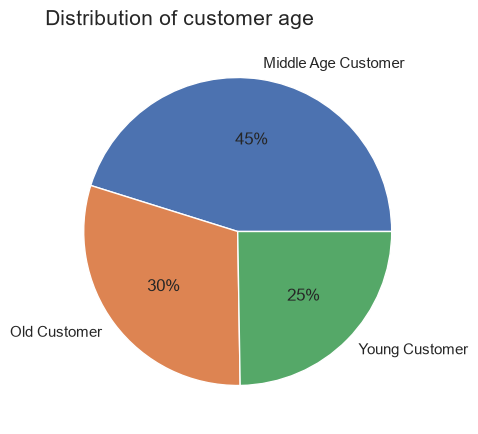

In [169]:
chart_age = df_ticket["Type of Customer"].value_counts()
plt.figure(figsize=(10, 5))
plt.pie(chart_age, labels=chart_age.index, autopct="%.0f%%")
plt.title("Distribution of customer age", loc="left", pad=10, size=15)
plt.show()

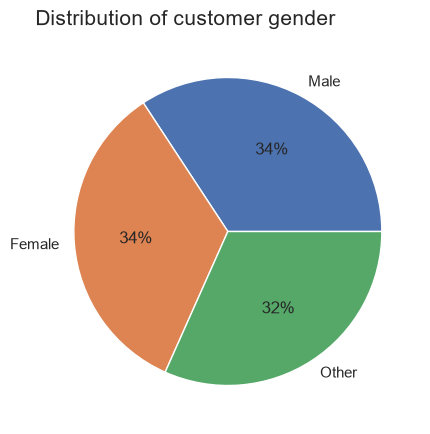

In [170]:
chart_gen = df_ticket["Customer Gender"].value_counts()
plt.figure(figsize=(10, 5))
plt.pie(chart_gen, labels=chart_gen.index, autopct="%.0f%%")
plt.title("Distribution of customer gender", loc="left", pad=10, size=15)
plt.show()

In [171]:
unique = len(df_ticket["Product Purchased"].unique())
print(f" Total of products was purchased: {unique}")

 Total of products was purchased: 43


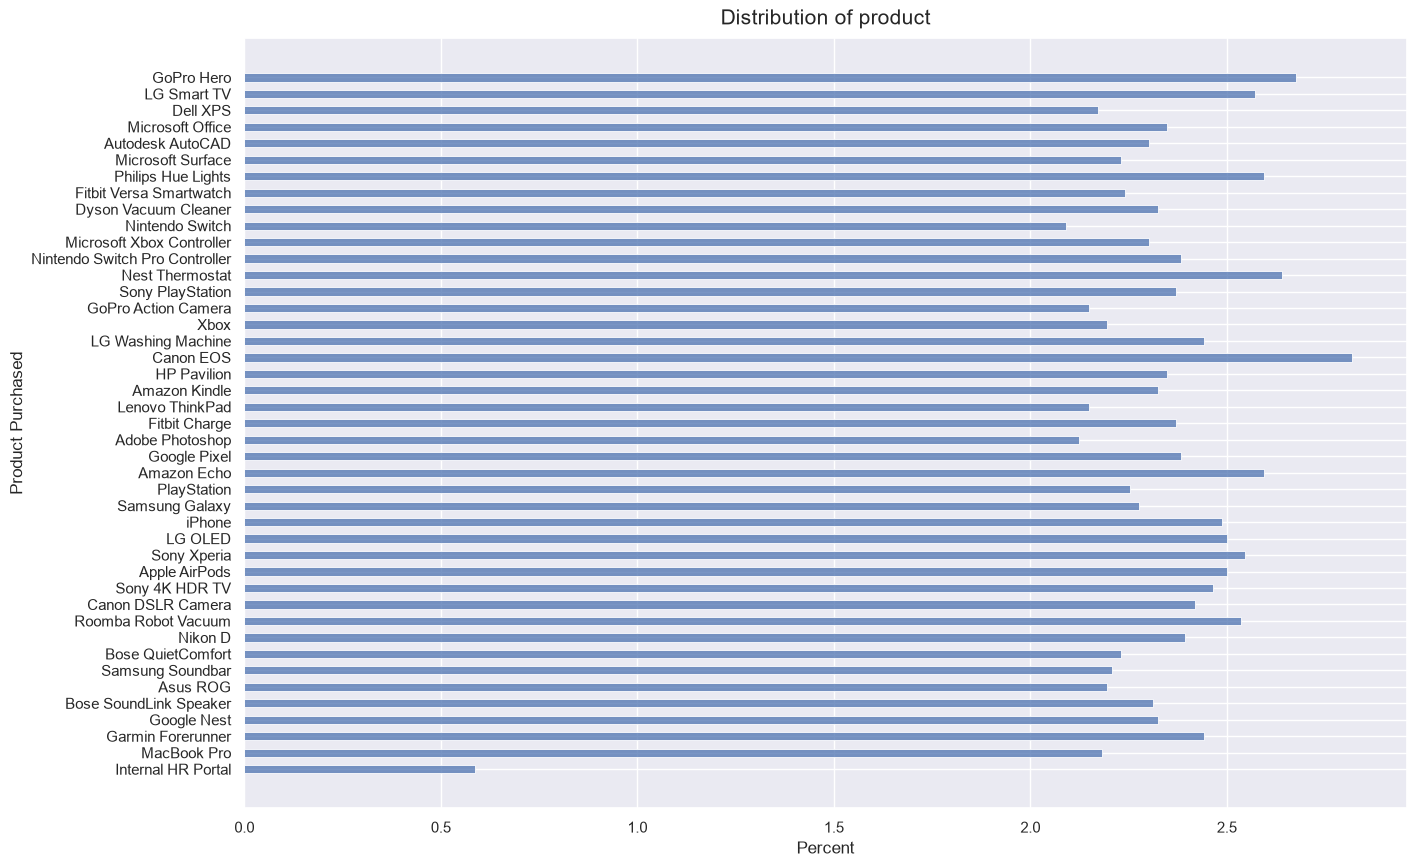

In [172]:
plt.figure(figsize=(15, 10))
sns.histplot(data=df_ticket, y="Product Purchased", stat="percent", shrink=0.5)
plt.title("Distribution of product", loc="center", pad=10, size=15)
plt.show()

### 4.2 Ticket Metrics & Channel Distribution

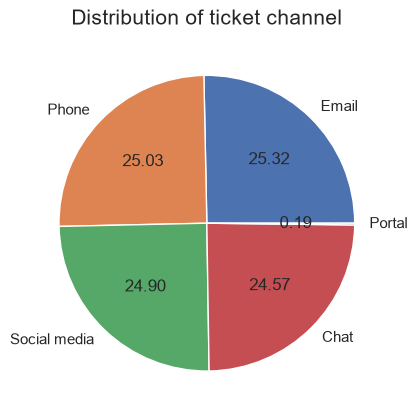

In [173]:
chart_chan = df_ticket["Ticket Channel"].value_counts()
plt.pie(chart_chan, labels=chart_chan.index, autopct="%.2f")
plt.title("Distribution of ticket channel", loc="center", pad=10, size=15)
plt.show()

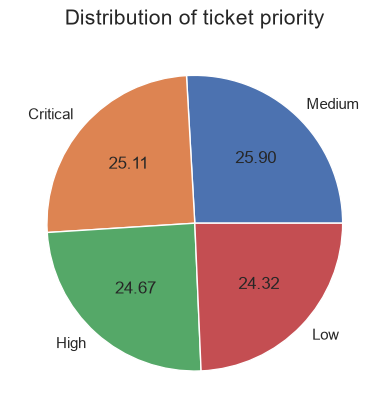

In [174]:
chart_prio = df_ticket["Ticket Priority"].value_counts()
plt.pie(chart_prio, labels=chart_prio.index, autopct="%.2f")
plt.title("Distribution of ticket priority", loc="center", pad=10, size=15)
plt.show()

### 4.3 Response & Resolution Rates

In [175]:
chance = []
for i in df_ticket["First Response Time"]:
    if i == "No response":
        chance.append("No")
    else:
        chance.append("Yes")
df_ticket["Response"] = chance

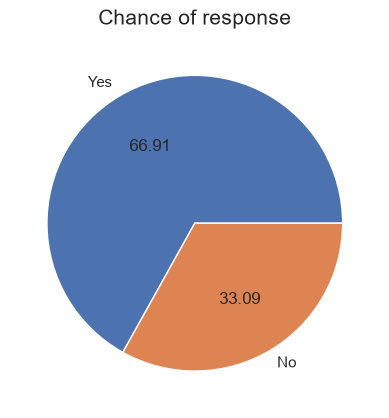

In [176]:
chart_res = df_ticket["Response"].value_counts()
plt.pie(chart_res, labels=chart_res.index, autopct="%.2f")
plt.title("Chance of response", loc="center", pad=10, size=15)
plt.show()

In [177]:
chance_r = []
for i in df_ticket["Time to Resolution"]:
    if i == "No resolution":
        chance_r.append("No")
    else:
        chance_r.append("Yes")
df_ticket["Resolution_bin"] = chance_r

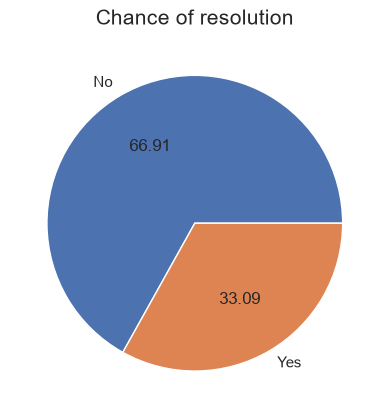

In [178]:
chart_re = df_ticket["Resolution_bin"].value_counts()
plt.pie(chart_re, labels=chart_re.index, autopct="%.2f")
plt.title("Chance of resolution", loc="center", pad=10, size=15)
plt.show()

In [179]:
df_ticket["Customer Satisfaction Rating"] = df_ticket["Customer Satisfaction Rating"].astype("object")
df_ticket["Customer Satisfaction Rating"].info()

<class 'pandas.Series'>
RangeIndex: 8519 entries, 0 to 8518
Series name: Customer Satisfaction Rating
Non-Null Count  Dtype 
--------------  ----- 
8519 non-null   object
dtypes: object(1)
memory usage: 66.7+ KB


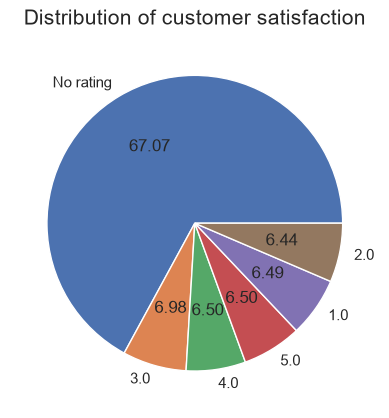

In [180]:
chart_satis = df_ticket["Customer Satisfaction Rating"].value_counts()
plt.pie(chart_satis, labels=chart_satis.index, autopct="%.2f")
plt.title("Distribution of customer satisfaction", loc="center", pad=10, size=15)
plt.show()

### 4.4 Priority & Channel Cross-Analysis

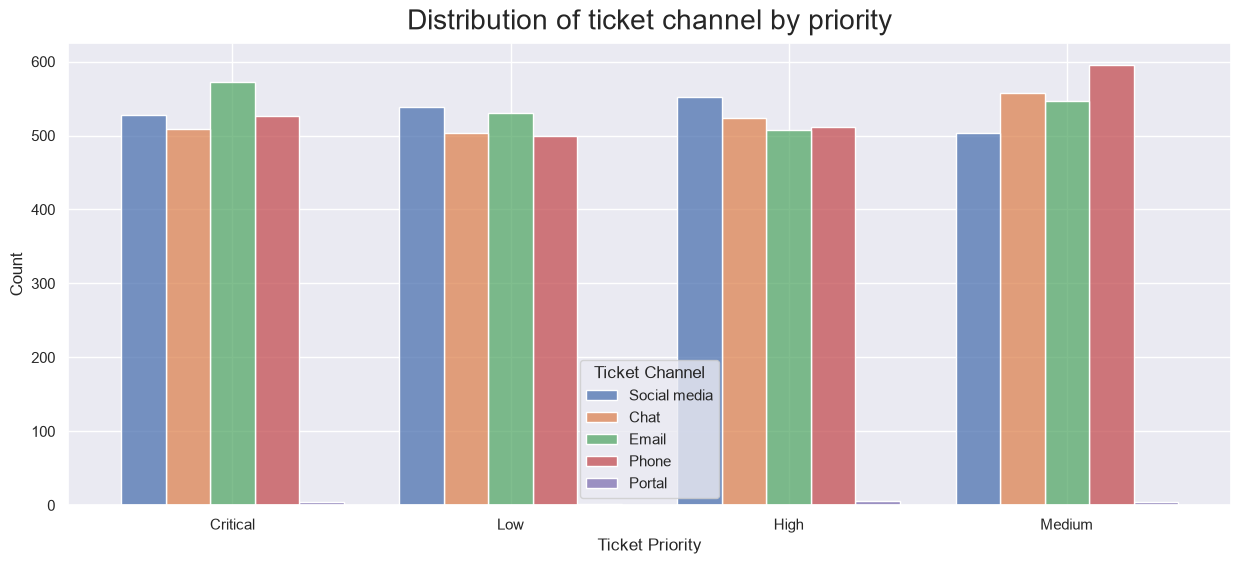

In [181]:
plt.figure(figsize=(15, 6))
sns.histplot(df_ticket, hue="Ticket Channel", x="Ticket Priority", multiple="dodge", shrink=0.8)
plt.title("Distribution of ticket channel by priority", loc="center", pad=10, size=20)
plt.show()

In [182]:
ticket_st = df_ticket["Ticket Status"].unique()
print(f"Ticket status: {list(ticket_st)}")

Ticket status: ['Pending Customer Response', 'Closed', 'Open', 'Resolved']


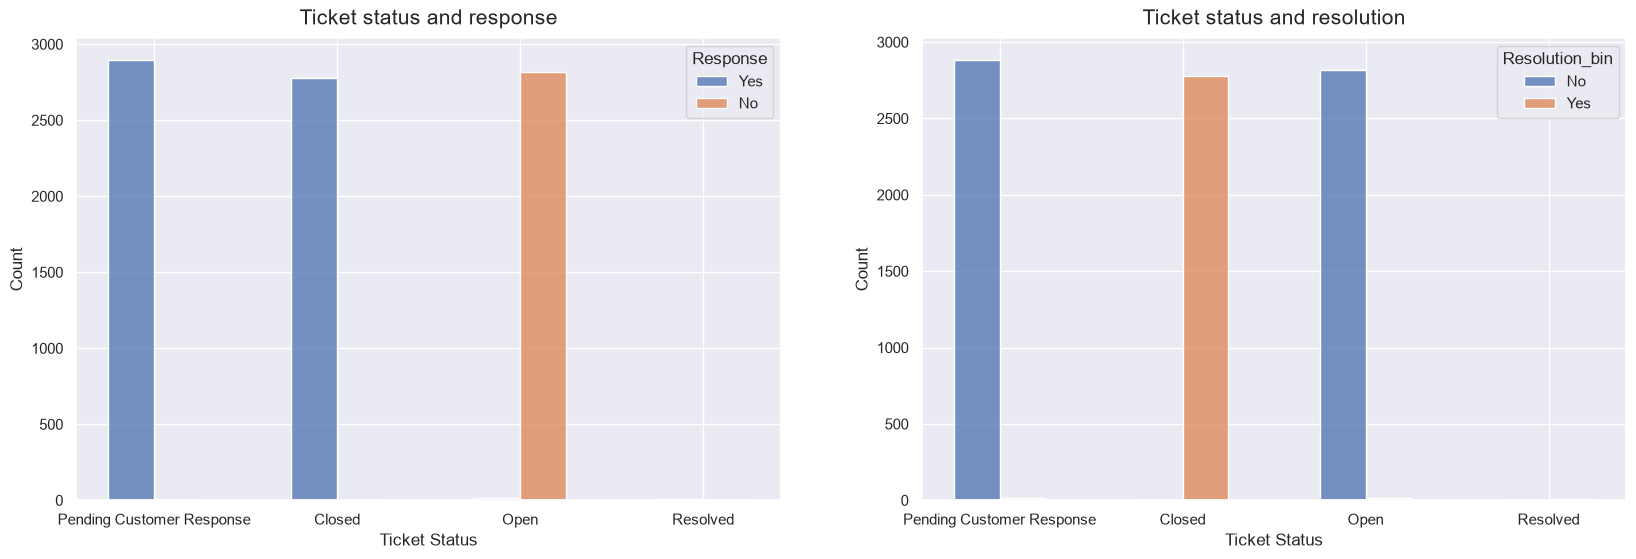

In [183]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.histplot(df_ticket, x="Ticket Status", hue="Response", multiple="dodge", shrink=0.5, ax=axes[0])
sns.histplot(df_ticket, x="Ticket Status", hue="Resolution_bin", multiple="dodge", shrink=0.5, ax=axes[1])
axes[0].set_title("Ticket status and response", loc="center", pad=10, size=15)
axes[1].set_title("Ticket status and resolution", loc="center", pad=10, size=15)
plt.show()

In [184]:
priority = pd.pivot_table(
    df_ticket,
    index=["Ticket Priority"],
    values=["Customer Name"],
    columns=["Resolution_bin"],
    aggfunc=len,
).reset_index()
priority = priority.rename(columns={"Customer Name": "Chance of Solution"})
priority["Percent"] = (priority["Chance of Solution"]["Yes"] / priority["Chance of Solution"]["No"]) * 100
priority

Ticket Priority Chance of Solution         Percent
Resolution_bin                                 No  Yes           
0                     Critical               1403  736  52.459016
1                         High               1380  722  52.318841
2                          Low               1419  653  46.018323
3                       Medium               1498  708  47.263017

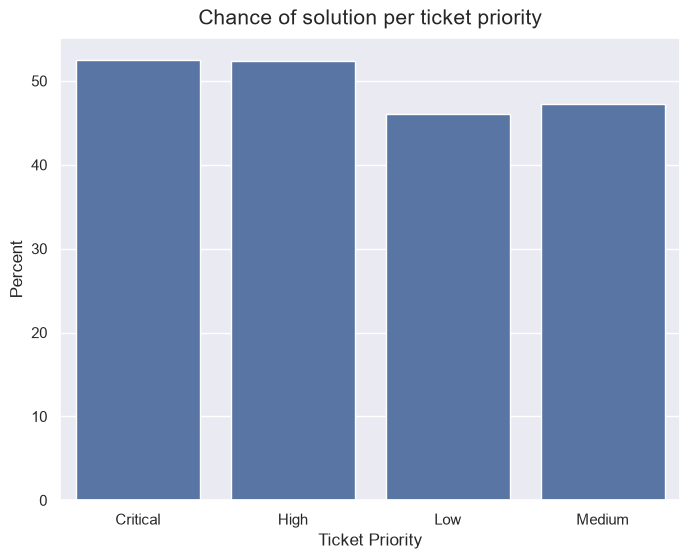

In [185]:
plt.figure(figsize=(8, 6))
sns.barplot(priority, x="Ticket Priority", y="Percent")
plt.title("Chance of solution per ticket priority", loc="center", pad=10, size=15)
plt.show()

In [186]:
rating = pd.pivot_table(
    df_ticket,
    index=["Customer Satisfaction Rating"],
    values=["Customer Name"],
    columns=["Resolution_bin"],
    aggfunc=len,
).reset_index()
rating = rating.rename(columns={"Customer Name": "Resolution"})
rating

Customer Satisfaction Rating Resolution       
Resolution_bin                                      No    Yes
0                                       1.0        NaN  553.0
1                                       2.0        NaN  549.0
2                                       3.0        NaN  595.0
3                                       4.0        NaN  554.0
4                                       5.0        NaN  554.0
5                                 No rating     5700.0   14.0

**Findings:**

* Customer age, gender, ticket priority and producted distribution is non-skewed.
* Customer's portal visite rate is extremely low. 

## 5. Deep Dive into Resolved Tickets

In [187]:
df_resolution = df_ticket[df_ticket["Resolution_bin"] == "Yes"].copy()
df_resolution.head()

,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Type of Customer,Response,Resolution_bin
2,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,Middle Age Customer,Yes,Yes
3,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,Young Customer,Yes,Yes
4,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,Old Customer,Yes,Yes
10,Joseph Moreno,mbrown@example.org,48,Male,Nintendo Switch,2021-01-19,Billing,Data loss,I'm having an issue with the {product_purchase...,Closed,Measure tonight surface feel forward.,High,Phone,2023-06-01 17:46:49,2023-05-31 23:51:49,1.0,Middle Age Customer,Yes,Yes
11,Brandon Arnold,davisjohn@example.net,51,Male,Microsoft Xbox Controller,2021-10-24,General,Software bug,I'm having an issue with the {product_purchase...,Closed,Measure there house management pick knowledge ...,High,Chat,2023-06-01 12:05:51,2023-06-01 09:27:51,1.0,Middle Age Customer,Yes,Yes


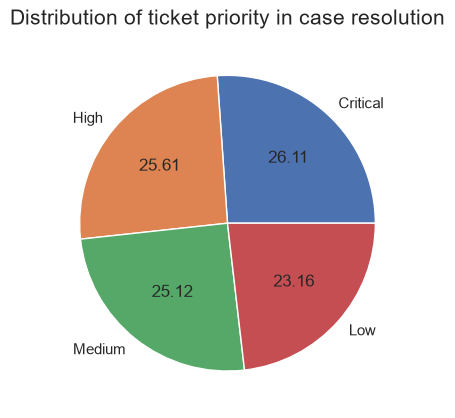

In [188]:
chart_reprio = df_resolution["Ticket Priority"].value_counts()
plt.pie(chart_reprio, labels=chart_reprio.index, autopct="%.2f")
plt.title("Distribution of ticket priority in case resolution", loc="center", pad=10, size=15)
plt.show()

In [189]:
rating = []
for i in df_resolution["Customer Satisfaction Rating"]:
    if isinstance(i, (int, float)) and i <= 2:
        rating.append("Low")
    elif isinstance(i, (int, float)) and i == 3:
        rating.append("Medium")
    else:
        rating.append("High")
df_resolution["Type of rating"] = rating

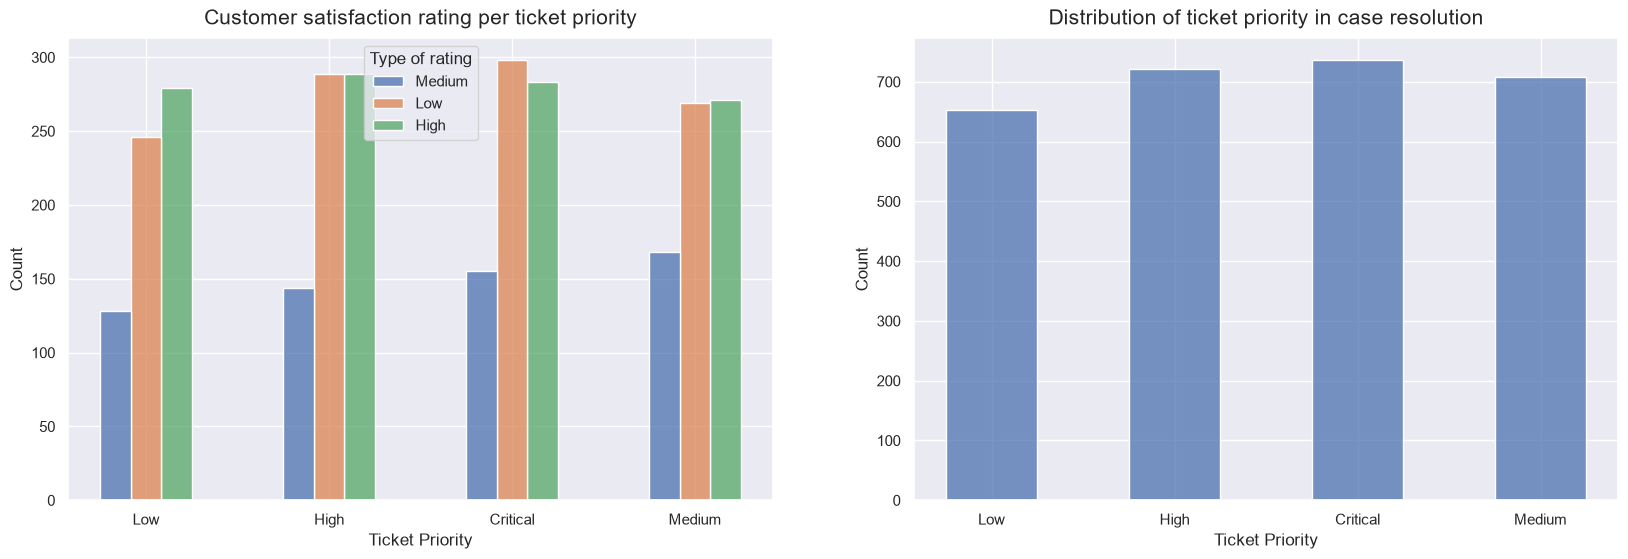

In [190]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.histplot(df_resolution, x="Ticket Priority", hue="Type of rating", multiple="dodge", shrink=0.5, ax=axes[0])
sns.histplot(df_resolution["Ticket Priority"], shrink=0.5, ax=axes[1])
axes[0].set_title("Customer satisfaction rating per ticket priority", loc="center", pad=10, size=15)
axes[1].set_title("Distribution of ticket priority in case resolution", loc="center", pad=10, size=15)
plt.show()

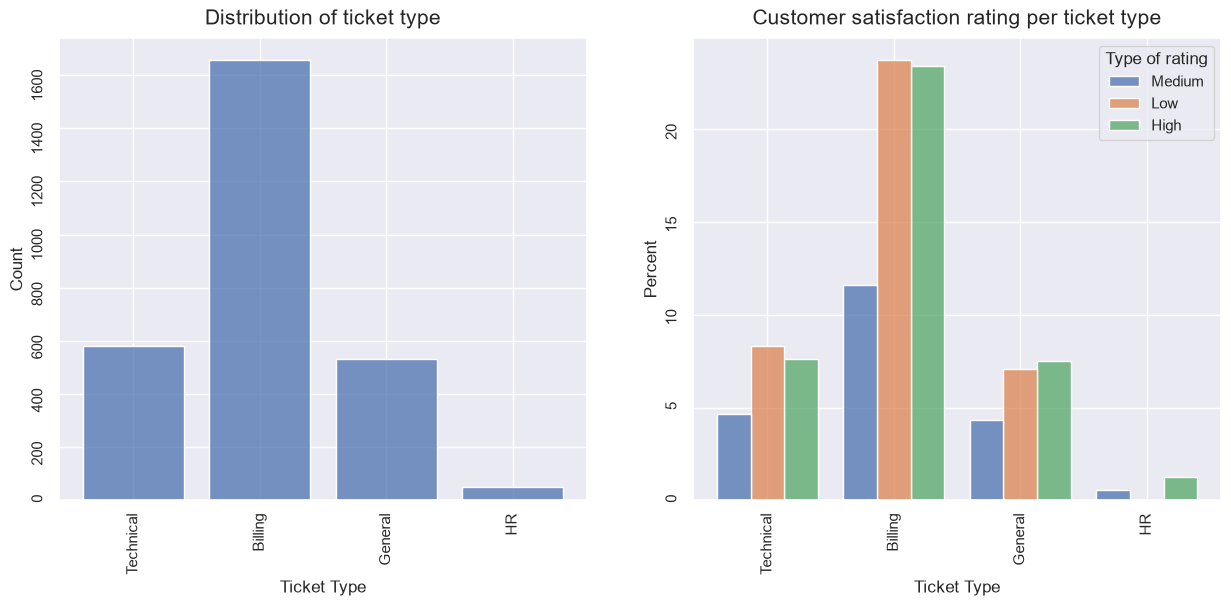

In [191]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(df_resolution["Ticket Type"], shrink=0.8, ax=axes[0])
sns.histplot(
    hue=df_resolution["Type of rating"],
    x=df_resolution["Ticket Type"],
    multiple="dodge",
    shrink=0.8,
    stat="percent",
    ax=axes[1],
)
axes[0].tick_params(labelrotation=90)
axes[1].tick_params(labelrotation=90)
axes[0].set_title("Distribution of ticket type", loc="center", pad=10, size=15)
axes[1].set_title("Customer satisfaction rating per ticket type", loc="center", pad=10, size=15)
plt.show()

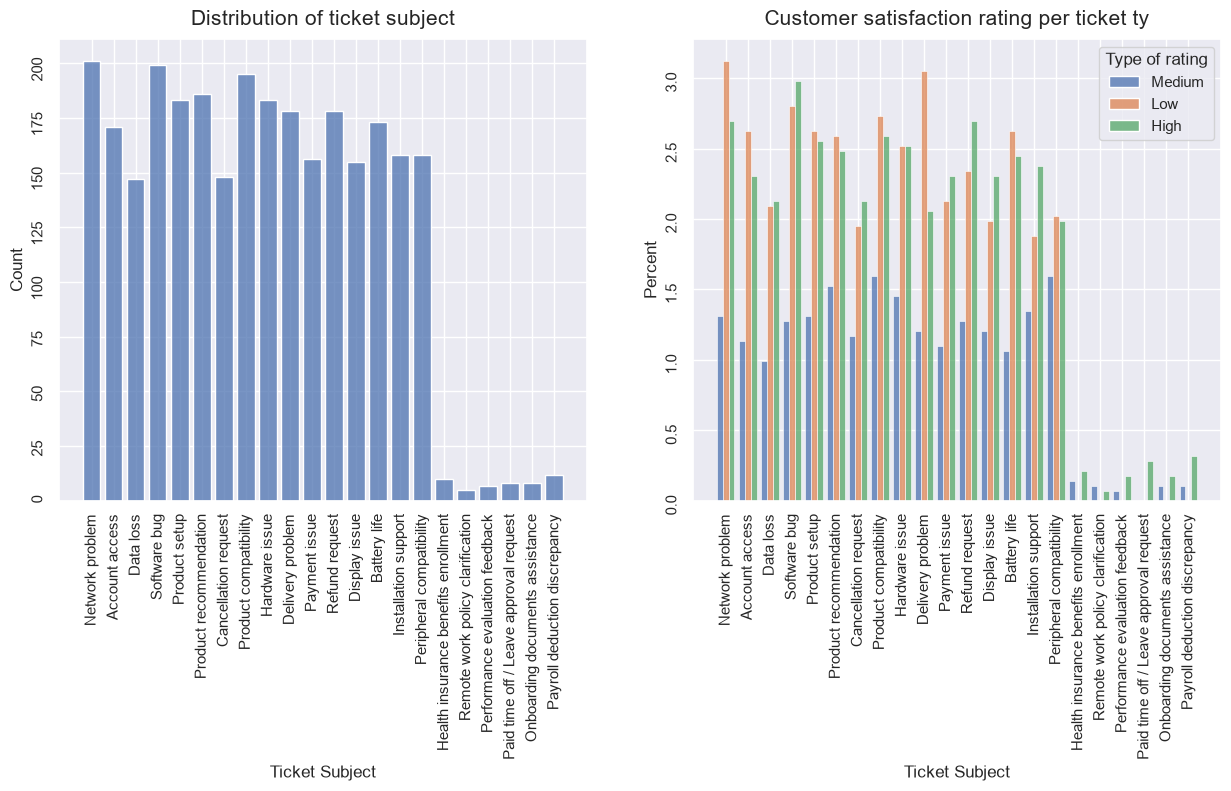

In [192]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(df_resolution["Ticket Subject"], shrink=0.8, ax=axes[0])
sns.histplot(
    hue=df_resolution["Type of rating"],
    x=df_resolution["Ticket Subject"],
    multiple="dodge",
    shrink=0.8,
    stat="percent",
    ax=axes[1],
)
axes[0].tick_params(labelrotation=90)
axes[1].tick_params(labelrotation=90)
axes[0].set_title("Distribution of ticket subject", loc="center", pad=10, size=15)
axes[1].set_title("Customer satisfaction rating per ticket ty", loc="center", pad=10, size=15)
plt.show()

## 6. NLP & Text Mining Analysis

### 6.1 Text Cleaning & Preprocessing

In [193]:
df_sentiment = df_ticket[
    ["Ticket Description", "Resolution", "Ticket Priority", "Ticket Subject", "Resolution_bin"]
].copy()
df_sentiment.head()

,Ticket Description,Resolution,Ticket Priority,Ticket Subject,Resolution_bin
0,I'm having an issue with the {product_purchase...,None,Critical,Product setup,No
1,I'm having an issue with the {product_purchase...,None,Critical,Peripheral compatibility,No
2,I'm facing a problem with my {product_purchase...,Case maybe show recently my computer follow.,Low,Network problem,Yes
3,I'm having an issue with the {product_purchase...,Try capital clearly never color toward story.,Low,Account access,Yes
4,I'm having an issue with the {product_purchase...,West decision evidence bit.,Low,Data loss,Yes


In [194]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[({})?/$#|=]", "", text)
    text = re.sub(r"\n", "", text)
    text = re.sub(r"[.]", " ", text)
    text = re.sub(r"[->]", " ", text)
    text = re.sub(r"[:]", " ", text)
    text = re.sub(r"[_]", " ", text)
    text = re.sub(r"[,]", " ", text)
    text = re.sub(r"[-]", " ", text)
    text = re.sub(r"[\']", " ", text)
    text = re.sub(r"<.*?>+", "", text)
    text = re.sub(r"\w*\d\w*", "", text)
    return text

In [195]:
df_sentiment["Ticket Description"] = df_sentiment["Ticket Description"].apply(lambda x: clean_text(x))

In [196]:
df_sentiment["Resolution"] = df_sentiment["Resolution"].apply(lambda x: clean_text(x))

In [197]:
new_stopwords = ["i'm", "i've", "would", "could", "-d", "-i'm", "[--]:", "not", "mm", "ca", "cs", "hi"]
stpwrd = nltk.corpus.stopwords.words("english")
stpwrd.extend(new_stopwords)

In [198]:
def remove_stopword(x):
    return [y for y in x if y not in stpwrd]

### 6.2 Word Frequency Analysis

In [199]:
df_sentiment["temp1"] = df_sentiment["Ticket Description"].apply(lambda x: str(x).split())
df_sentiment["temp1"] = df_sentiment["temp1"].apply(lambda x: remove_stopword(x))
top = Counter([item for sublist in df_sentiment["temp1"] for item in sublist])
temp = pd.DataFrame(top.most_common(20))
temp.columns = ["Common_words", "count"]

<Axes: xlabel='count', ylabel='Common_words'>

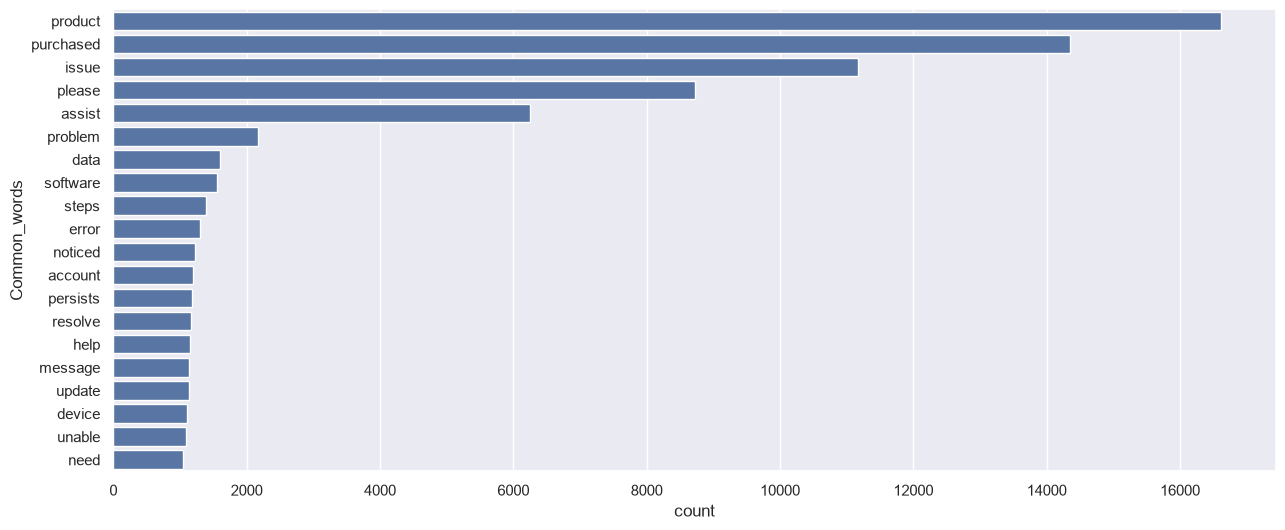

In [200]:
plt.figure(figsize=(15, 6))
sns.barplot(temp, y="Common_words", x="count")

In [201]:
df_sentiment_resolution = df_sentiment[df_sentiment["Resolution_bin"] == "Yes"].copy()

In [202]:
df_sentiment_resolution["temp2"] = df_sentiment_resolution["Resolution"].apply(lambda x: str(x).split())
df_sentiment_resolution["temp2"] = df_sentiment_resolution["temp2"].apply(lambda x: remove_stopword(x))
top = Counter([item for sublist in df_sentiment_resolution["temp2"] for item in sublist])
temp = pd.DataFrame(top.most_common(20))
temp.columns = ["Common_words", "count"]

<Axes: xlabel='count', ylabel='Common_words'>

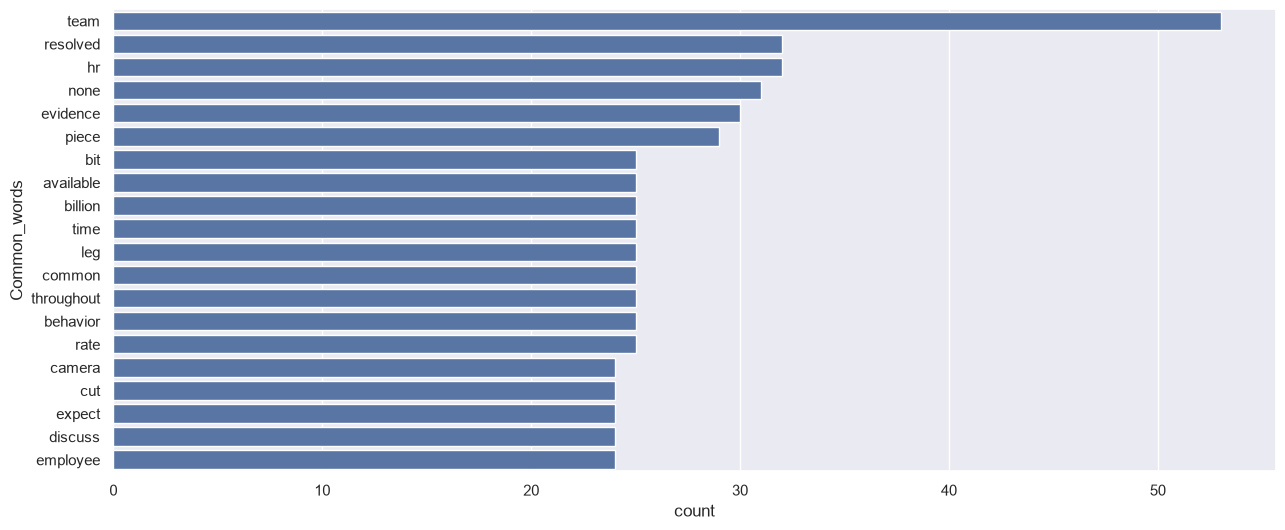

In [139]:
plt.figure(figsize=(15, 6))
sns.barplot(temp, y="Common_words", x="count")

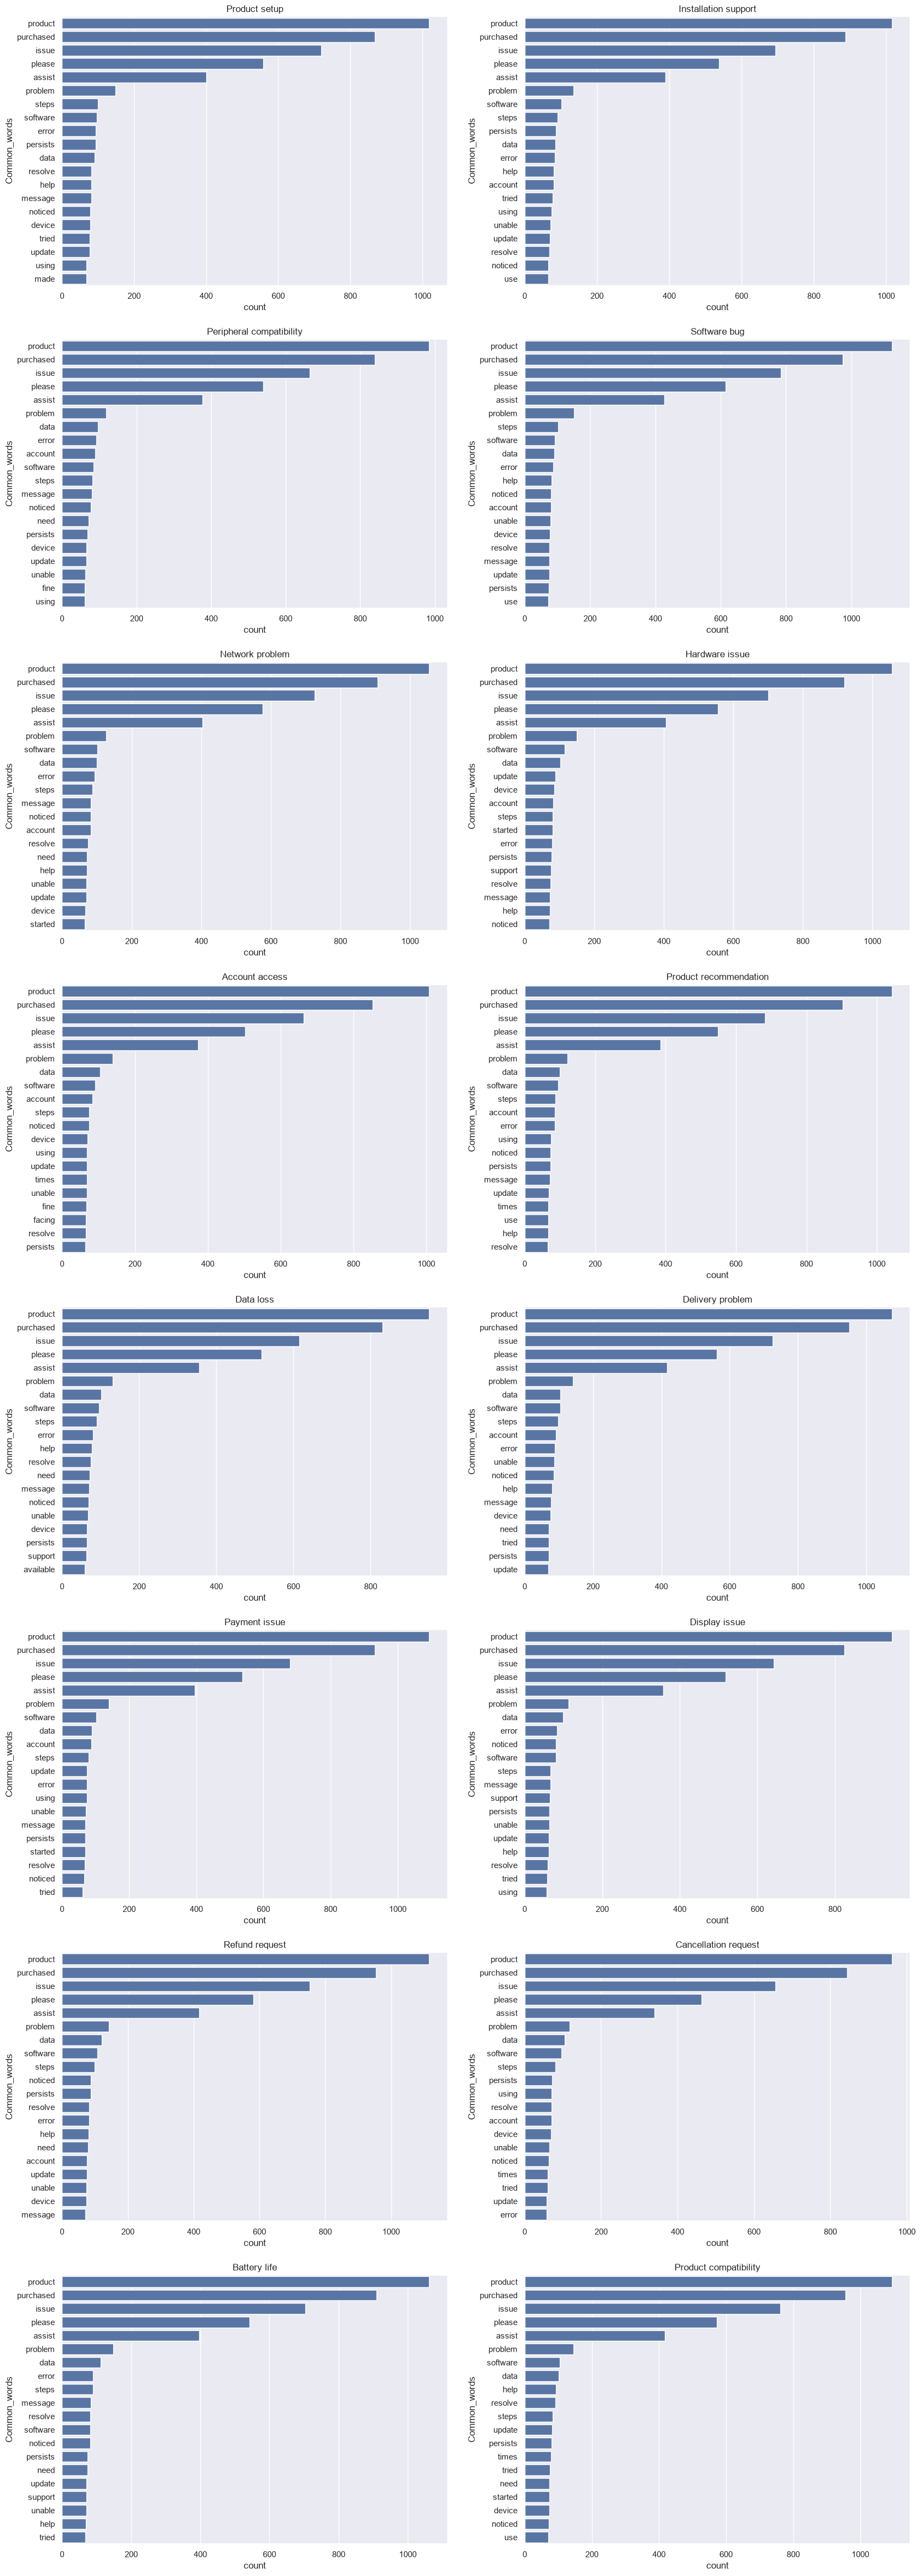

In [140]:
fig, axes = plt.subplots(8, 2, figsize=(20, 60))
for i, col in enumerate(df_sentiment["Ticket Subject"].unique()):
    idx = i % 8
    idr = i // 8
    table = df_sentiment[df_sentiment["Ticket Subject"] == col].copy()
    table["temp"] = table["Ticket Description"].apply(lambda x: str(x).split())
    table["temp"] = table["temp"].apply(lambda x: remove_stopword(x))
    top = Counter([item for sublist in table["temp"] for item in sublist])
    temp = pd.DataFrame(top.most_common(20))
    temp.columns = ["Common_words", "count"]
    if idr < 2:
        sns.barplot(temp, y="Common_words", x="count", ax=axes[idx, idr])
        axes[idx, idr].set_title(col)
plt.show()

### 6.3 Distinctive Key Term Extraction & Word Clouds

In [141]:
raw_text = [word for word_list in df_sentiment["temp1"] for word in word_list]

In [142]:
def unique_word(sentiment, numwords, raw_words):
    allother = []
    for item in df_sentiment[df_sentiment.Resolution_bin != sentiment]["temp1"]:
        for word in item:
            allother.append(word)
    allother = list(set(allother))

    specific = [x for x in raw_text if x not in allother]

    mycounter = Counter()

    for item in df_sentiment[df_sentiment.Resolution_bin == sentiment]["temp1"]:
        for word in item:
            mycounter[word] += 1
    keep = list(specific)

    for word in list(mycounter):
        if word not in keep:
            del mycounter[word]

    Unique_words = pd.DataFrame(mycounter.most_common(numwords), columns=["words", "count"])

    return Unique_words

In [143]:
resolve = unique_word("Yes", 20, raw_text)
resolve.style.background_gradient(cmap="Greens")

,words,count
0,reimbursement,12
1,deduction,11
2,stub,11
3,dependent,11
4,formal,9
5,seeking,7
6,employment,7
7,consumers,4
8,font,4
9,gist,4


In [144]:
none = unique_word("No", 20, raw_text)
none.style.background_gradient(cmap="Blues")

,words,count
0,property,12
1,perfect,9
2,gaming,9
3,decided,8
4,wants,8
5,platform,8
6,]game,8
7,suggest,7
8,isp,7
9,willing,7


In [145]:
df_sentiment_resolution

,Ticket Description,Resolution,Ticket Priority,Ticket Subject,Resolution_bin,temp1,temp2
2,i m facing a problem with my product purchased...,case maybe show recently my computer follow,Low,Network problem,Yes,"[facing, problem, product, purchased, product,...","[case, maybe, show, recently, computer, follow]"
3,i m having an issue with the product purchased...,try capital clearly never color toward story,Low,Account access,Yes,"[issue, product, purchased, please, assist, pr...","[try, capital, clearly, never, color, toward, ..."
4,i m having an issue with the product purchased...,west decision evidence bit,Low,Data loss,Yes,"[issue, product, purchased, please, assist, no...","[west, decision, evidence, bit]"
10,i m having an issue with the product purchased...,measure tonight surface feel forward,High,Data loss,Yes,"[issue, product, purchased, please, assist, pr...","[measure, tonight, surface, feel, forward]"
11,i m having an issue with the product purchased...,measure there house management pick knowledge ...,High,Software bug,Yes,"[issue, product, purchased, please, assist, po...","[measure, house, management, pick, knowledge, ..."
...,...,...,...,...,...,...,...
8514,submitting formal request for annual leave fro...,none,Low,Health insurance benefits enrollment,Yes,"[submitting, formal, request, annual, leave, n...",[none]
8515,i noticed an unexpected deduction on my recent...,resolved by hr team,Low,Payroll deduction discrepancy,Yes,"[noticed, unexpected, deduction, recent, pay, ...","[resolved, hr, team]"
8516,could you guide me through adding a dependent ...,resolved by hr team,Critical,Health insurance benefits enrollment,Yes,"[guide, adding, dependent, medical, plan]","[resolved, hr, team]"
8517,need clarification regarding company policy on...,resolved by hr team,Medium,Onboarding documents assistance,Yes,"[need, clarification, regarding, company, poli...","[resolved, hr, team]"


In [146]:
def unique_word(sentiment, numwords, raw_words):
    allother = []
    for item in df_sentiment_resolution[df_sentiment_resolution.Resolution_bin != sentiment]["temp2"]:
        for word in item:
            allother.append(word)
    allother = list(set(allother))

    specific = [x for x in raw_text if x not in allother]

    mycounter = Counter()

    for item in df_sentiment_resolution[df_sentiment_resolution.Resolution_bin == sentiment]["temp2"]:
        for word in item:
            mycounter[word] += 1
    keep = list(specific)

    for word in list(mycounter):
        if word not in keep:
            del mycounter[word]

    Unique_words = pd.DataFrame(mycounter.most_common(numwords), columns=["words", "count"])

    return Unique_words

In [147]:
resolve = unique_word("Yes", 20, raw_text)
resolve.style.background_gradient(cmap="Greens")

,words,count
0,team,53
1,resolved,32
2,none,31
3,piece,29
4,bit,25
5,available,25
6,time,25
7,common,25
8,behavior,25
9,rate,25


In [148]:
def plot_wordcloud(
    text,
    mask=None,
    max_words=200,
    max_font_size=30,
    figure_size=(20, 10),
    color="white",
    title=None,
    title_size=40,
    image_color=False,
):
    stopwords_set = set(STOPWORDS)

    wordcloud = WordCloud(
        background_color=color,
        stopwords=stopwords_set,
        max_words=max_words,
        max_font_size=max_font_size,
        random_state=42,
        width=400,
        height=200,
        mask=mask,
    )
    wordcloud.generate(str(text))

    plt.figure(figsize=figure_size)
    if image_color:
        image_colors = ImageColorGenerator(mask)
        plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear")
        plt.title(title, fontdict={"size": title_size, "verticalalignment": "bottom"})
    else:
        plt.imshow(wordcloud)
        plt.title(title, fontdict={"size": title_size, "color": "black", "verticalalignment": "bottom"})
    plt.axis("off")
    plt.tight_layout()

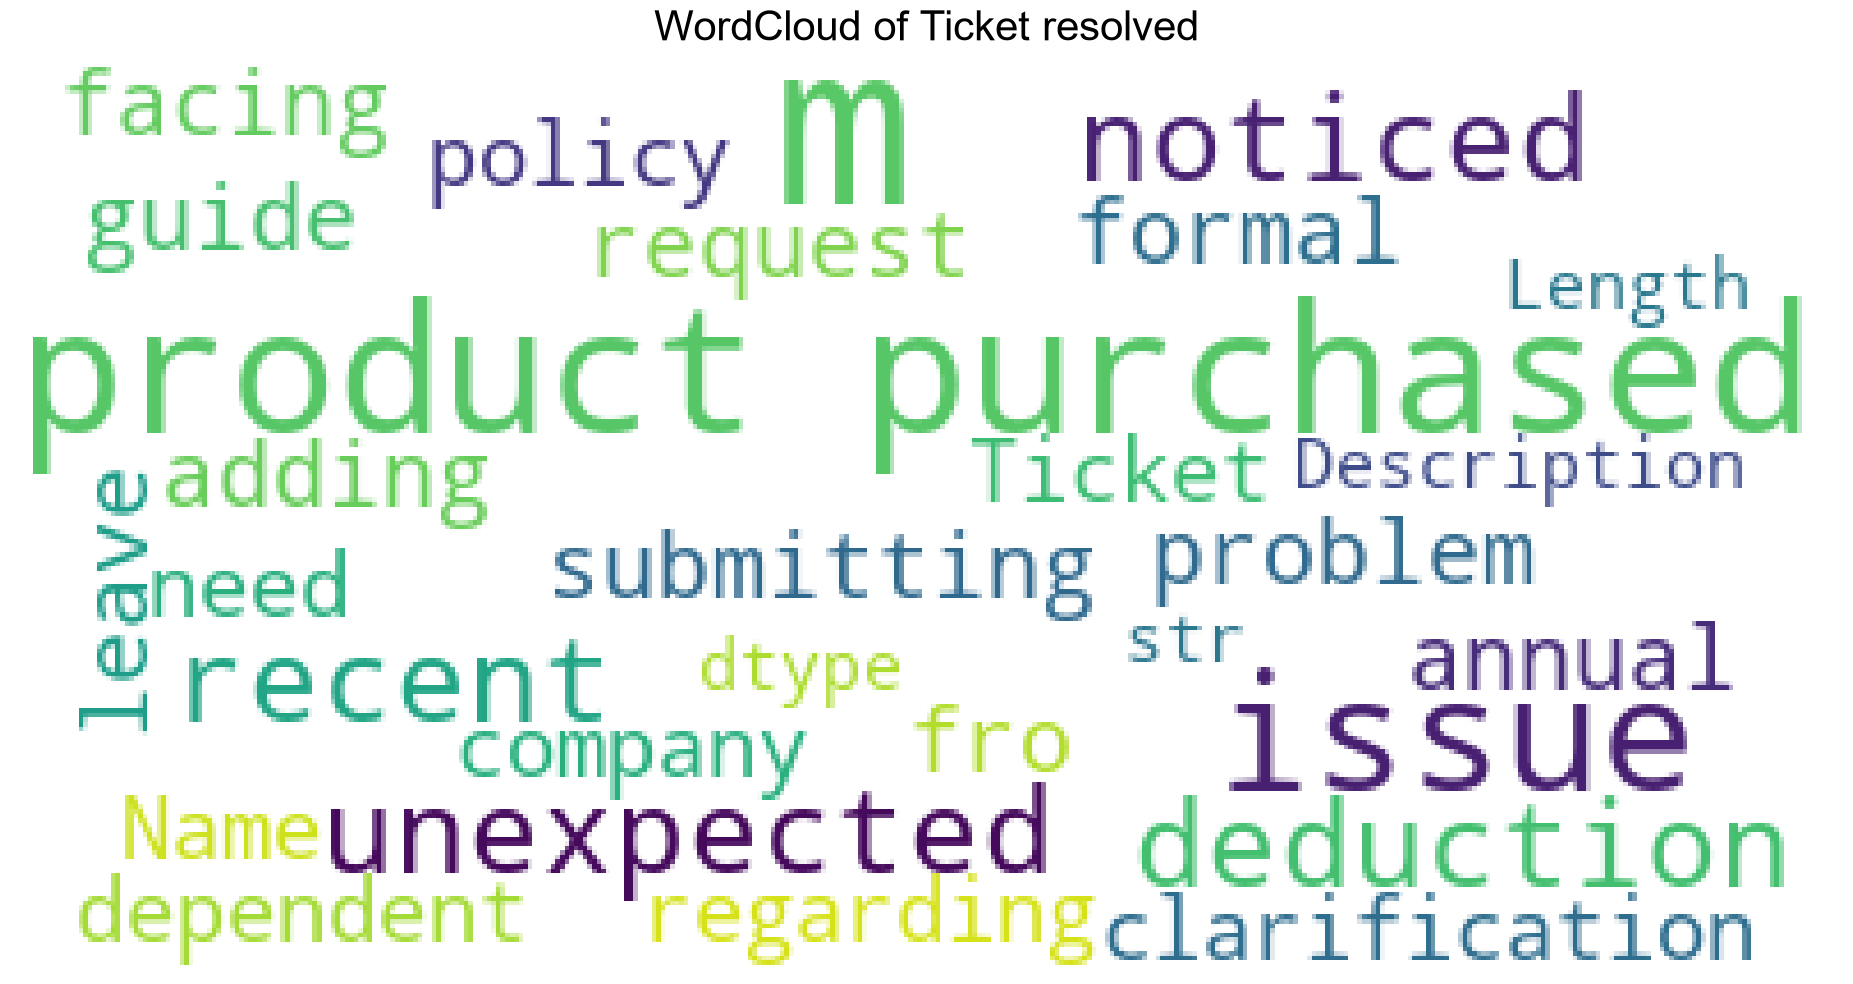

In [149]:
plot_wordcloud(
    df_sentiment[df_sentiment["Resolution_bin"] == "Yes"]["Ticket Description"],
    mask=None,
    color="white",
    max_font_size=50,
    title_size=30,
    title="WordCloud of Ticket resolved",
)

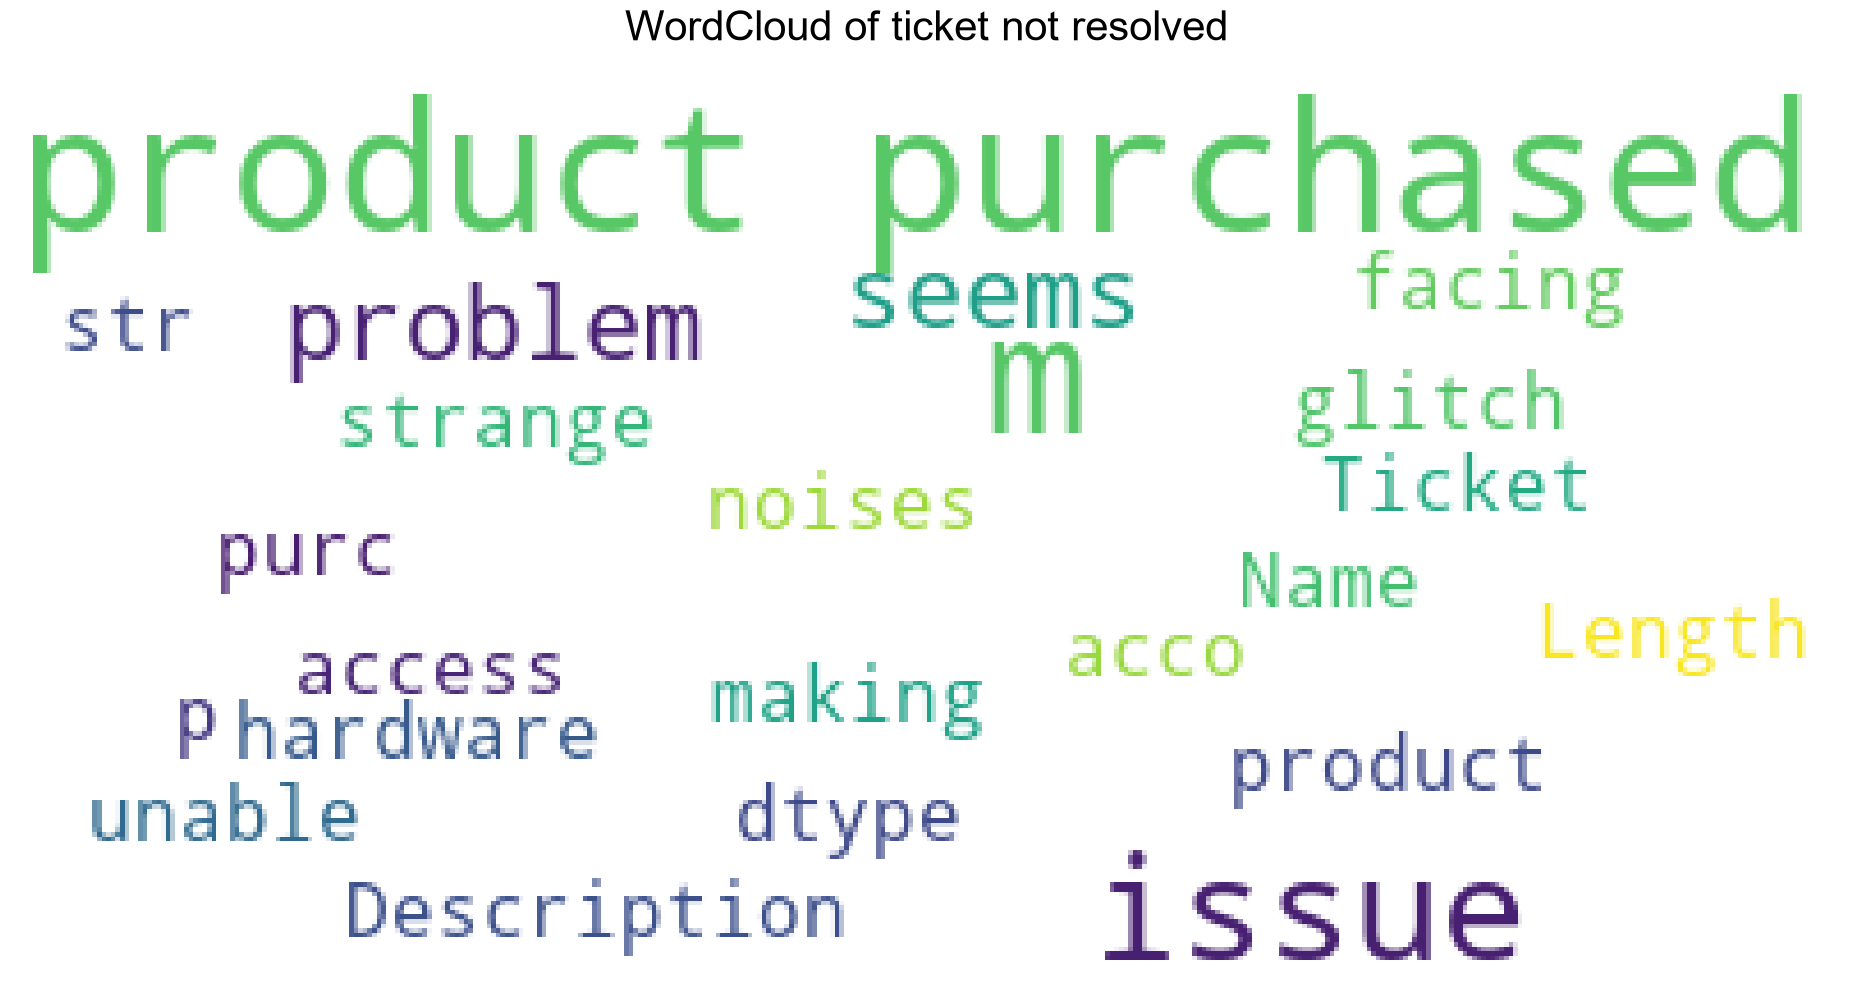

In [150]:
plot_wordcloud(
    df_sentiment[df_sentiment["Resolution_bin"] == "No"]["Ticket Description"],
    mask=None,
    color="white",
    max_font_size=50,
    title_size=30,
    title="WordCloud of ticket not resolved",
)

## 7. Resolution Time Interval Analysis

In [151]:
valid_dates_mask = (df_resolution["Time to Resolution"].notnull()) & (df_resolution["First Response Time"].notnull()) & (df_resolution["Time to Resolution"] != "No resolution") & (df_resolution["First Response Time"] != "No response")
df_resolution.loc[valid_dates_mask, "Interval"] = (
    pd.to_datetime(df_resolution.loc[valid_dates_mask, "Time to Resolution"])
    - pd.to_datetime(df_resolution.loc[valid_dates_mask, "First Response Time"])
)

In [152]:
df_resolution["Interval"] = round(df_resolution["Interval"].dt.total_seconds() / (3600.0), 2)

In [153]:
df_resolution["Interval"].describe()

count    2819.000000
mean        0.400043
std        10.072645
min       -23.230000
25%        -6.740000
50%         0.370000
75%         7.010000
max        25.750000
Name: Interval, dtype: float64

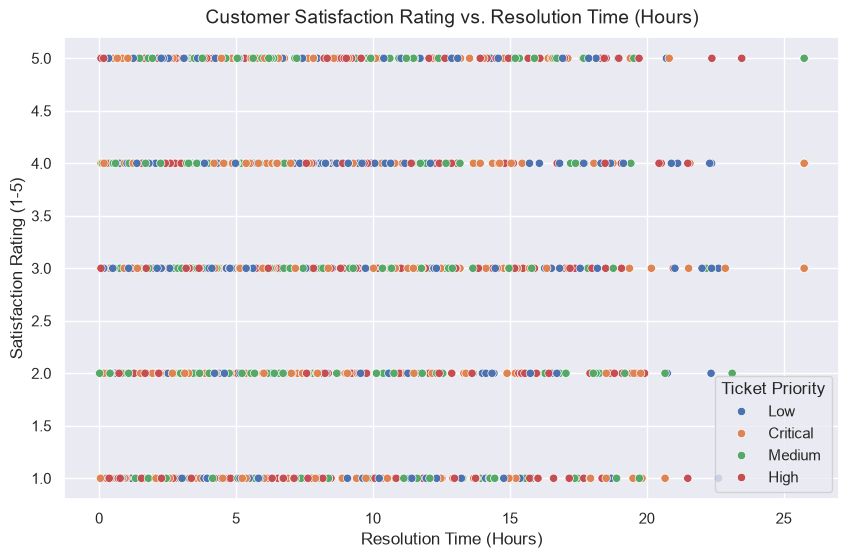

In [154]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plot_data = df_resolution[
    (df_resolution["Interval"] > 0) & 
    (df_resolution["Customer Satisfaction Rating"] != "No rating")
].copy()

plot_data["Customer Satisfaction Rating"] = pd.to_numeric(plot_data["Customer Satisfaction Rating"])

sns.scatterplot(
    data=plot_data,
    x="Interval",
    y="Customer Satisfaction Rating",
    hue="Ticket Priority",
)

plt.title("Customer Satisfaction Rating vs. Resolution Time (Hours)", pad=10, size=14)
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Satisfaction Rating (1-5)")
plt.show()